--- Répartition des cas (Positifs / Négatifs) ---
diabetes
0    91500
1     8500
Name: count, dtype: int64

--- Étape 1 : Encodage et Standardisation réussis ! ---
--- Étape 2 : Entraînement du modèle réussi ! ---
--- Étape 3 : Prédictions générées avec succès ! ---



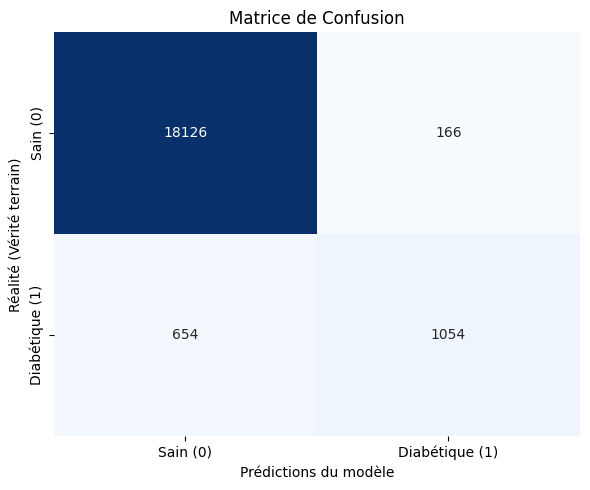

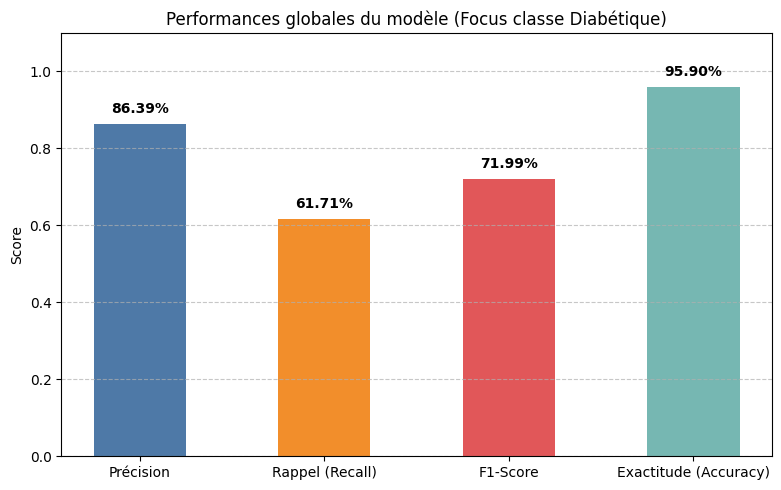

c:\Users\pc\Desktop\DI-BOOTCAMP\.venv-2\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


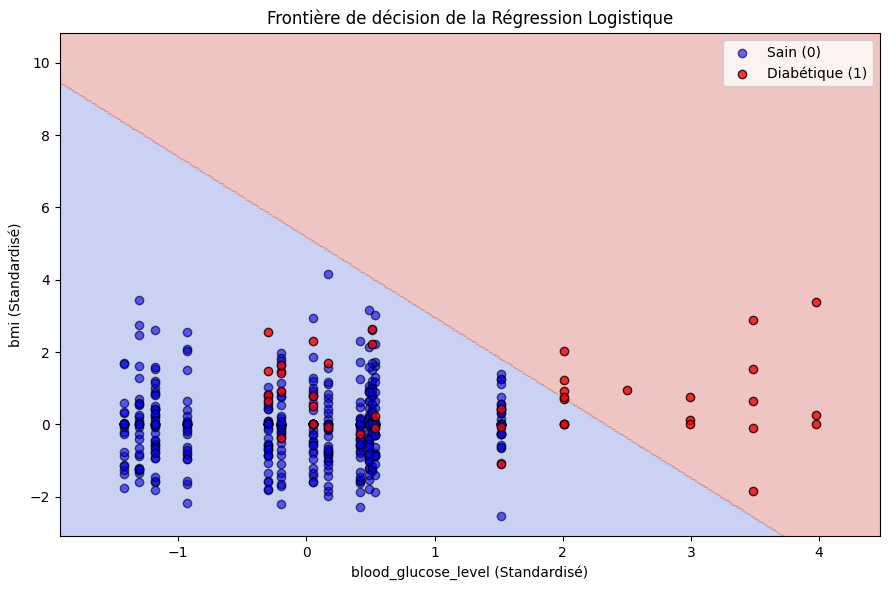

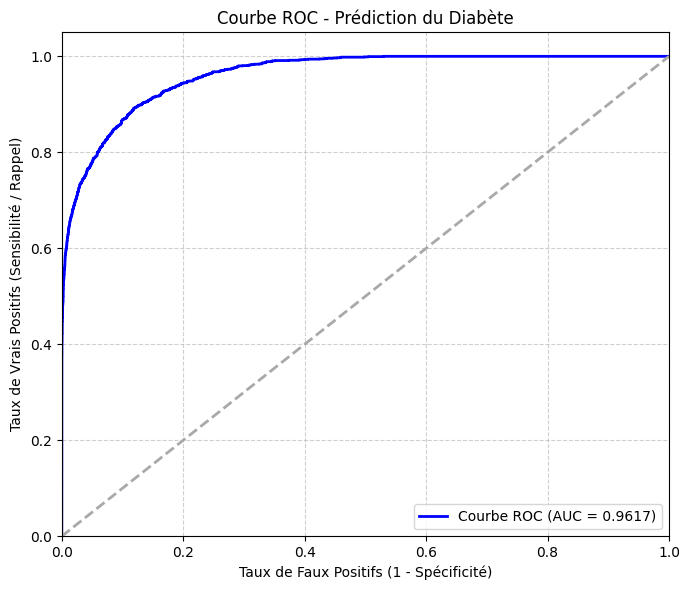

Score AUC global du modèle : 0.9617


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snsl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, roc_auc_score


#  Exercice 1 : Compréhension du problème et collecte de données

df = pd.read_csv('Diabetes prediction dataset\\diabetes_prediction_dataset.csv')

# 2. Décompte des cas positifs et négatifs
colonne_cible = 'diabetes'
print("--- Répartition des cas (Positifs / Négatifs) ---")
print(df[colonne_cible].value_counts())

# 3. Encodage et Division des données (Ta structure initiale)
df_encode = pd.get_dummies(df, drop_first=True)
X = df_encode.drop(columns=[colonne_cible])
y = df_encode[colonne_cible]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#  Exercice 2 : Sélection et standardisation des modèles
colonnes_numeriques = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colonnes_numeriques] = scaler.fit_transform(X_train[colonnes_numeriques])
X_test_scaled[colonnes_numeriques] = scaler.transform(X_test[colonnes_numeriques])
print("\n--- Étape 1 : Encodage et Standardisation réussis ! ---")


#  Exercice 3 : Formation sur modèle
modele = LogisticRegression(random_state=42, max_iter=1000)
modele.fit(X_train_scaled, y_train)
print("--- Étape 2 : Entraînement du modèle réussi ! ---")

y_pred = modele.predict(X_test_scaled)
y_pred_proba = modele.predict_proba(X_test_scaled)[:, 1]
print("--- Étape 3 : Prédictions générées avec succès ! ---\n")


# Exercice 4 : Métriques d'évaluation
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
accuracy = accuracy_score(y_test, y_pred)

# Graphique 1 : Matrice de Confusion
plt.figure(figsize=(6, 5))
snsl.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Sain (0)', 'Diabétique (1)'],
            yticklabels=['Sain (0)', 'Diabétique (1)'])
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions du modèle')
plt.ylabel('Réalité (Vérité terrain)')
plt.tight_layout()
plt.show()

# Graphique 2 : Barplot des Métriques
metrics_class_1 = {
    'Précision': report['1']['precision'],
    'Rappel (Recall)': report['1']['recall'],
    'F1-Score': report['1']['f1-score'],
    'Exactitude (Accuracy)': accuracy
}

plt.figure(figsize=(8, 5))
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
bars = plt.bar(metrics_class_1.keys(), metrics_class_1.values(), color=colors, width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2%}", ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.1)
plt.title('Performances globales du modèle (Focus classe Diabétique)')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#  Exercice 5 : Visualisation des performances (Frontière de décision)
var1 = 'blood_glucose_level'
var2 = 'bmi'

model_2d = LogisticRegression(random_state=42, max_iter=1000)
model_2d.fit(X_train_scaled[[var1, var2]], y_train)

x_min, x_max = X_test_scaled[var1].min() - 0.5, X_test_scaled[var1].max() + 0.5
y_min, y_max = X_test_scaled[var2].min() - 0.5, X_test_scaled[var2].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

sample = X_test_scaled.sample(500, random_state=42)
y_sample = y_test.loc[sample.index]

plt.scatter(sample[var1][y_sample == 0], sample[var2][y_sample == 0], alpha=0.6, label='Sain (0)', color='blue', edgecolors='k')
plt.scatter(sample[var1][y_sample == 1], sample[var2][y_sample == 1], alpha=0.8, label='Diabétique (1)', color='red', edgecolors='k')

plt.title('Frontière de décision de la Régression Logistique')
plt.xlabel(f'{var1} (Standardisé)')
plt.ylabel(f'{var2} (Standardisé)')
plt.legend()
plt.tight_layout()
plt.show()


#  Exercice 6 : Courbe ROC

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Courbe ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='darkgray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taux de Faux Positifs (1 - Spécificité)")
plt.ylabel("Taux de Vrais Positifs (Sensibilité / Rappel)")
plt.title("Courbe ROC - Prédiction du Diabète")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Score AUC global du modèle : {auc_score:.4f}")

#1. Commentaire sur le Score d'Exactitude (Accuracy) et de Précision
#Exactitude (Accuracy) : Elle est généralement très élevée sur ce dataset (souvent autour de 96%). Cela montre que le modèle ne se trompe que très rarement sur l'ensemble des prédictions.
#Précision (pour la classe 1 - Diabétique) : Elle indique le pourcentage de vrais diabétiques parmi toutes les personnes que le modèle a prédites comme diabétiques. Si elle est de 85%, cela signifie que lorsque le modèle dit "Cette personne est malade", il a raison 85 fois sur 100. C'est crucial pour éviter les faux diagnostics positifs qui génèrent du stress inutile chez les patients.

#2. Commentaire sur la Matrice de Confusion
#La matrice de confusion te montre 4 cadrans indispensables :

#Vrais Négatifs (Top-Left) : Les personnes saines bien prédites comme saines (le chiffre le plus grand, car la majorité de la population est saine).

#Faux Positifs (Top-Right) : Les personnes saines que le modèle a détectées malades par erreur.

#Faux Négatifs (Bottom-Left) : Le point le plus critique en médecine. Ce sont les personnes réellement diabétiques que le modèle a ratées (prédites comme saines).

#Vrais Positifs (Bottom-Right) : Les personnes malades correctement identifiées.

#3. Commentaire sur le Rappel (Recall) et le Score F1
#Rappel (Recall) : C'est la capacité du modèle à intercepter tous les malades. Si le rappel est un peu plus bas que la précision (par exemple 70%), cela signifie que la régression logistique a tendance à laisser filer quelques patients malades sans les détecter (Faux Négatifs). En médecine, on cherche souvent à avoir le rappel le plus proche de 100% possible.
#Score F1 : C'est la moyenne harmonique entre la précision et le rappel. Il donne une idée globale de l'efficacité du modèle sur la classe minoritaire (les diabétiques). Plus il est proche de 100%, plus le modèle est équilibré.